# XGBoost Dark Matter Estimation on SPARC Data
1. Combines the 4 SPARC training datasets (`galaxies.csv`, `stellar-masses.csv`, `BTF.csv`, `newt-mass.csv`) into a single master file `data/sparc_combined_train.csv` while keeping all 4 separate CSVs intact.
2. Calculates physical target Dark Matter Fraction ($f_{\text{DM}}$) from rotation curve decomposition at outer radius $R_{\text{max}}$.
3. Preprocesses galaxy features (masses, radii, surface brightness, rotation speed, color, morph type).
4. Trains an XGBoost regression model with 5-fold cross-validation.
5. Uses SHAP to identify which observable properties most determine dark matter fraction and dark halo mass.


In [1]:
# Run once — comment out after first run
# !pip install xgboost scikit-learn pandas numpy shap --quiet

In [2]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("All imports successful.")
print(f"XGBoost version: {xgb.__version__}")

/Users/aaravsharma/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.
XGBoost version: 3.4.0


In [3]:
USE_SYNTHETIC      = False          # Set True only for synthetic test fallback
TRAIN_DIR          = "data/train"
COMBINED_CSV_PATH  = "data/train/combined/sparc_combined_train.csv"

FEATURE_COLS = [
    "stellar_mass_logM",
    "HI_gas_mass_MHI",
    "baryonic_mass_logMb",
    "effective_radius_Reff",
    "surface_brightness_SBeff",
    "disk_scale_length_Rdisk",
    "rotation_velocity_Vflat",
    "color_3p6_4p5",
    "morph_type_T",
]

TARGET_COL   = "dm_fraction"
RANDOM_STATE = 42
N_FOLDS      = 5

In [4]:
from create_combined_sparc_dataset import build_combined_sparc_dataset

def make_synthetic_sparc(n=175, seed=42):
    """Synthetic SPARC-like fallback data."""
    rng = np.random.default_rng(seed)
    stellar_mass = 10 ** rng.uniform(7, 12, n) / 1e9
    gas_mass     = stellar_mass * rng.uniform(0.05, 2.0, n)
    luminosity   = stellar_mass * rng.uniform(0.5, 3.0, n)
    radius       = rng.uniform(1, 30, n)
    surf_bright  = luminosity / (np.pi * radius**2)
    vflat        = rng.uniform(50, 350, n)
    dm_fraction  = np.clip(
        1.0 - surf_bright / surf_bright.max() * 0.8 + rng.normal(0, 0.1, n),
        0.05, 0.98
    )
    return pd.DataFrame({
        "Galaxy":                      [f"SYN_{i:03d}" for i in range(n)],
        "stellar_mass_logM":           np.log10(stellar_mass * 1e9),
        "HI_gas_mass_MHI":             gas_mass,
        "baryonic_mass_logMb":         np.log10((stellar_mass + gas_mass) * 1e9),
        "effective_radius_Reff":       radius,
        "surface_brightness_SBeff":    surf_bright,
        "disk_scale_length_Rdisk":     radius * 0.6,
        "rotation_velocity_Vflat":     vflat,
        "color_3p6_4p5":               rng.uniform(2.5, 4.5, n),
        "morph_type_T":                rng.integers(1, 11, n),
        "dm_fraction":                 dm_fraction,
    })

if USE_SYNTHETIC:
    df = make_synthetic_sparc()
    print("Using synthetic data (175 galaxies)")
else:
    # Generate combined dataset from 4 separate CSVs if not present
    if not os.path.exists(COMBINED_CSV_PATH):
        df = build_combined_sparc_dataset(train_dir=TRAIN_DIR, output_csv=COMBINED_CSV_PATH)
    else:
        df = pd.read_csv(COMBINED_CSV_PATH)
        print(f"Loaded combined dataset from '{COMBINED_CSV_PATH}' ({len(df)} galaxies)")

print(f"Shape: {df.shape}")
df[["Galaxy", "stellar_mass_logM", "HI_gas_mass_MHI", "baryonic_mass_logMb", "effective_radius_Reff", "surface_brightness_SBeff", "rotation_velocity_Vflat", "dm_fraction"]].head()

Loaded combined dataset from 'data/train/combined/sparc_combined_train.csv' (140 galaxies)
Shape: (140, 18)


,Galaxy,stellar_mass_logM,HI_gas_mass_MHI,baryonic_mass_logMb,effective_radius_Reff,surface_brightness_SBeff,rotation_velocity_Vflat,dm_fraction
0,UGC08286,8.990000,0.642,9.170000,2.25,39.52,82.4,0.796715
1,UGC07232,7.704000,0.046,8.070000,0.46,83.34,35.2,0.384627
2,UGC01230,9.580925,6.430,10.092085,6.45,28.63,103.7,0.760355
3,UGC05986,9.370606,2.667,9.770000,3.12,76.71,113.0,0.726667
4,UGC06983,9.446000,2.967,9.828573,3.95,53.56,109.0,0.694897


In [5]:
available = [c for c in FEATURE_COLS if c in df.columns]
missing   = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"WARNING — missing columns (skipped): {missing}")

df_clean = df[available + [TARGET_COL]].dropna().reset_index(drop=True)
print(f"Galaxies after dropping NaN rows: {len(df_clean)}")

X = df_clean[available].copy()
y = df_clean[TARGET_COL].values
feature_names = list(X.columns)
X_arr = X.values.astype(float)

print(f"Feature matrix shape: {X_arr.shape}")
print(f"DM fraction range: [{y.min():.3f}, {y.max():.3f}]")
X.describe()

Galaxies after dropping NaN rows: 140
Feature matrix shape: (140, 9)
DM fraction range: [0.000, 0.927]


,stellar_mass_logM,HI_gas_mass_MHI,baryonic_mass_logMb,effective_radius_Reff,surface_brightness_SBeff,disk_scale_length_Rdisk,rotation_velocity_Vflat,color_3p6_4p5,morph_type_T
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,9.519133,4.560207,9.808471,3.661214,416.228929,2.850214,118.956786,3.187714,6.757143
std,1.144354,7.011514,0.894246,2.360129,667.238526,2.329176,68.665814,0.497360,2.905889
min,7.192000,0.012000,7.730000,0.320000,5.360000,0.200000,18.600000,1.600000,0.000000
25%,8.720966,0.668750,9.199754,1.892500,22.742500,1.390000,65.900000,3.112500,4.000000
50%,9.362182,1.722500,9.752111,3.120000,76.710000,2.400000,98.350000,3.140000,7.000000
75%,10.679938,4.530750,10.625000,5.022500,480.657500,3.567500,168.925000,3.145000,9.250000
max,11.607000,33.428000,11.300000,10.710000,3317.650000,18.760000,314.600000,5.080000,11.000000


### XGBoost Regressor Configuration
| Parameter | Value | Rationale |
|---|---|---|
| `max_depth` | 3 | Shallow trees prevent overfitting on small astronomical datasets |
| `learning_rate` | 0.05 | Shrinkage step size for gradual ensemble learning |
| `subsample` | 0.8 | Row subsampling per tree |
| `colsample_bytree` | 0.8 | Feature subsampling per tree |
| `reg_alpha` | 0.1 | L1 regularization |
| `reg_lambda` | 1.0 | L2 regularization |


In [6]:
def build_model():
    return xgb.XGBRegressor(
        n_estimators     = 300,
        max_depth        = 3,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        objective        = "reg:squarederror",
        eval_metric      = "rmse",
        random_state     = RANDOM_STATE,
        verbosity        = 0,
    )

print("Model config:")
print(build_model())

Model config:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [7]:
try:
    dm_bins = pd.qcut(y, q=N_FOLDS, labels=False, duplicates="drop")
    kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    splits = list(kf.split(X_arr, dm_bins))
except Exception:
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    splits = list(kf.split(X_arr))

fold_results = []
all_y_true   = []
all_y_pred   = []
all_shap     = []

for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = X_arr[train_idx], X_arr[test_idx]
    y_train, y_test = y[train_idx],     y[test_idx]

    model = build_model()
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred = model.predict(X_test)
    r2     = r2_score(y_test, y_pred)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))

    fold_results.append({"Fold": fold+1, "R2": r2, "MAE": mae, "RMSE": rmse})
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    all_shap.append(np.abs(shap_vals))

    print(f"Fold {fold+1}: R²={r2:+.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}")

df_folds = pd.DataFrame(fold_results)
print(f"\nMean R²  : {df_folds['R2'].mean():.3f} ± {df_folds['R2'].std():.3f}")
print(f"Mean MAE : {df_folds['MAE'].mean():.4f} ± {df_folds['MAE'].std():.4f}")
print(f"Mean RMSE: {df_folds['RMSE'].mean():.4f} ± {df_folds['RMSE'].std():.4f}")

Fold 1: R²=+0.311  MAE=0.1686  RMSE=0.2135
Fold 2: R²=+0.398  MAE=0.1660  RMSE=0.2036
Fold 3: R²=+0.461  MAE=0.1502  RMSE=0.2068
Fold 4: R²=+0.206  MAE=0.1736  RMSE=0.2314
Fold 5: R²=+0.392  MAE=0.1502  RMSE=0.1989

Mean R²  : 0.354 ± 0.098
Mean MAE : 0.1617 ± 0.0109
Mean RMSE: 0.2108 ± 0.0126


In [8]:
# Fold performance summary table
df_folds.round({"R2": 3, "MAE": 4, "RMSE": 4})

,Fold,R2,MAE,RMSE
0,1,0.311,0.1686,0.2135
1,2,0.398,0.1660,0.2036
2,3,0.461,0.1502,0.2068
3,4,0.206,0.1736,0.2314
4,5,0.392,0.1502,0.1989


In [9]:
# Train final model on full dataset
final_model = build_model()
final_model.fit(X_arr, y, verbose=False)

explainer_final = shap.TreeExplainer(final_model)
shap_values     = explainer_final.shap_values(X_arr)

# Compute global feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature":        feature_names,
    "Mean |SHAP|":    mean_abs_shap,
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

importance_df["Rank"] = range(1, len(importance_df)+1)
print("Feature importance ranking (SHAP):")
importance_df[["Rank","Feature","Mean |SHAP|"]]

Feature importance ranking (SHAP):


,Rank,Feature,Mean |SHAP|
0,1,rotation_velocity_Vflat,0.103341
1,2,stellar_mass_logM,0.084010
2,3,HI_gas_mass_MHI,0.055180
3,4,baryonic_mass_logMb,0.054008
4,5,surface_brightness_SBeff,0.053214
5,6,effective_radius_Reff,0.029410
6,7,disk_scale_length_Rdisk,0.026423
7,8,morph_type_T,0.022199
8,9,color_3p6_4p5,0.008604


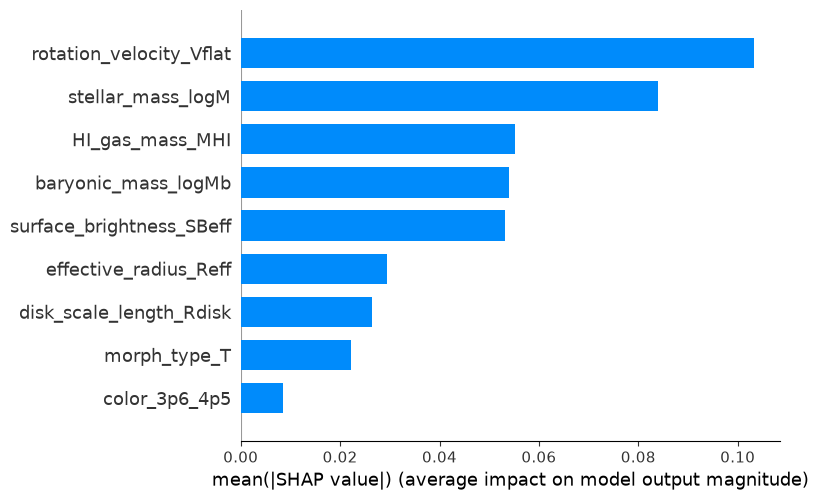

In [10]:
# ANSWERS RESEARCH QUESTION: Which observable properties are most determinative of dark matter fraction
shap.summary_plot(
    shap_values,
    X_arr,
    feature_names = feature_names,
    plot_type     = "bar",
    show          = True,
)